## module 1 — improved classifier

resnet50 fine-tune with fine-grained upgrades. **you only customize two cells here** — the *augmentation* and the *model / optimizer / schedule*. all the plumbing (data loading, VRAM-aware batching, resumable checkpointing across local · colab · kaggle, the training loop) lives in `bvtrain/`.

runs anywhere; resumable. share your best with `python -m share.publish`.

In [1]:
# get bvtrain (shared training plumbing): locally it's ../bvtrain; on colab/kaggle we clone the repo
import os, sys
_CANDS = ["..", ".", "botanical-vision"]
if not any(os.path.isdir(f"{p}/bvtrain") for p in _CANDS):
    os.system("git clone -q https://github.com/babnigg/botanical-vision.git")
for _p in _CANDS:
    if os.path.isdir(f"{_p}/bvtrain"):
        sys.path.insert(0, _p)
        break

import torch
import torch.nn as nn
from torchvision import models, transforms
import bvtrain as bv

In [2]:
env = bv.setup()

device: cuda | data: local | env: local


In [3]:
N_SPECIES = 100   # int (e.g. 100) for a quick subset run, None for all 4,094 species
data = bv.load_data(env, n_species=N_SPECIES)

100 species | {'train': 6974, 'test': 1500, 'val': 1499}


In [4]:
# ── customize: augmentation ──
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.RandAugment(),
    transforms.ToTensor(),
    transforms.Normalize(bv.MEAN, bv.STD),
    transforms.RandomErasing(p=0.25),
])

In [5]:
# ── customize: model, optimizer, schedule ──
EPOCHS = 15
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, data.n_labels)
model = model.to(env.device)

# discriminative lr: pretrained backbone learns slowly, fresh head faster
head = list(model.fc.parameters())
backbone = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
optimizer = torch.optim.AdamW(
    [{"params": backbone, "lr": 1e-4}, {"params": head, "lr": 1e-3}],
    weight_decay=1e-2,
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [6]:
loaders = bv.build_loaders(data, train_tf, env)
hist = bv.fit(model, optimizer, loaders, epochs=EPOCHS, run_name="resnet50_improved",
              env=env, scheduler=scheduler, criterion=criterion)

BATCH 8 x ACCUM 8 = eff 64 | workers 0 | amp True
fresh run


epoch 1/15 train:   0%|          | 0/872 [00:00<?, ?it/s]

epoch 1/15 val:   0%|          | 0/188 [00:00<?, ?it/s]

epoch 1: train_loss 3.973 acc 0.147 | val_loss 2.824 acc 0.391


epoch 2/15 train:   0%|          | 0/872 [00:00<?, ?it/s]

...

epoch 14/15 val:   0%|          | 0/188 [00:00<?, ?it/s]

epoch 14: train_loss 1.335 acc 0.885 | val_loss 1.830 acc 0.720


epoch 15/15 train:   0%|          | 0/872 [00:00<?, ?it/s]

epoch 15/15 val:   0%|          | 0/188 [00:00<?, ?it/s]

epoch 15: train_loss 1.333 acc 0.887 | val_loss 1.824 acc 0.716
best val acc: 0.722


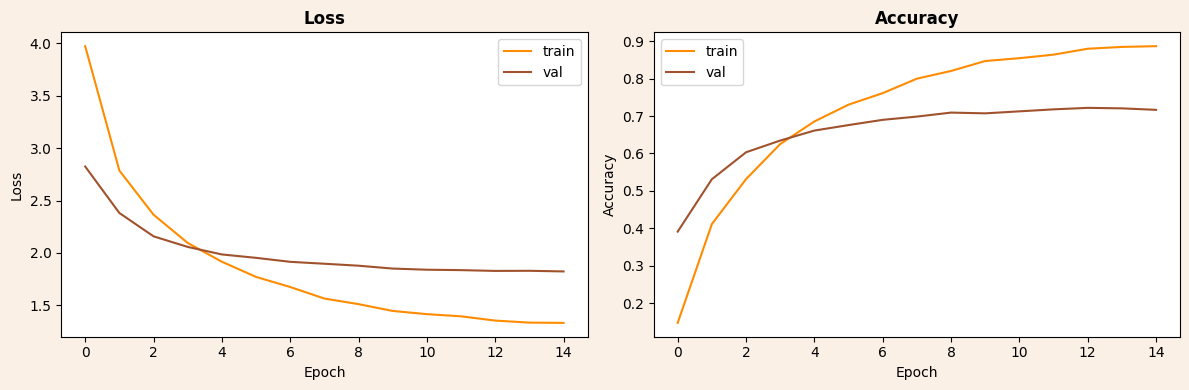

test:   0%|          | 0/188 [00:00<?, ?it/s]

test top-1: 0.704
test top-5: 0.897


{'top1': 0.704, 'top5': 0.8973333333333333}

In [7]:
bv.plot_history(hist)
bv.evaluate(model, loaders.test, env, run_name="resnet50_improved")